<a href="https://colab.research.google.com/github/gartuz/data-science-examples/blob/main/detecci_n_de_anomal_as_grupo_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección de anomalías - Introducción al análisis numérico - Grupo 6

## Integrantes:

Christopher Acosta Madrigal - C20050

David Meléndez Aguilar - C04726

Fabián Vega Meza - C08369

Gabriel Martínez Cruz - A33044

Jose Julián Hernández Monge - C23762

Sebastián Venegas Brenes - C18440

### Introducción

Analizaremos la **presión dinámica del viento** registrada en Niigata, Japón, durante **ocho días** (192 mediciones horarias).  
Para garantizar la calidad de los datos aplicaremos un detector de anomalías que usa:

- **Ventanas temporales deslizantes** de tamaño `H` horas (p. ej. `H = 1`, `23` o `47`),  
- Un **umbral γ** definido como `γ · σ`, donde `σ` es la desviación estándar.

Con la configuración base `H = 1 h` y `γ = 3 σ` evaluamos cada medición horaria; valores mayores de `H` permiten comparar bloques diarios o bienales.

**Objetivos del preprocesado**

1. Eliminar ruido y errores de medición comunes en big data meteorológico.  
2. Destacar patrones reales de la acción del viento sobre edificaciones.  
3. Mejorar la confiabilidad de cualquier conclusión ingenieril posterior.

En resumen, se muestra cómo una detección sencilla de outliers convierte grandes volúmenes de datos atmosféricos en información fiable para la toma de decisiones.


In [ ]:
H = 1 # Esto se puede descomentar para cambiar a un paso por cada hora es mas preciso para detectar outliers sin modificar el gamma_umbral. Nota: Aqui estamos dando 192 pasos
gamma_umbral = 3 # Usamos gamma_umbral veces la desviación estándar

In [ ]:
from IPython import get_ipython
from IPython.display import display

# niigata_wind.csv: Datos Normales en Niigata Japon
# niigata_wind_2.csv: Otra semana cualquiera en Niigata Japon

# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import UnivariateSpline # Importamos UnivariateSpline

#  Cargar datos
df = pd.read_csv('niigata_wind.csv')

# Calcular presión dinámica q_z = 0.5 * rho * V^2
rho = 1.225  # kg/m³ (densidad del aire)
df['qz'] = 0.5 * rho * (df['wspd']**2)

# Por simplicidad, creamos un vector de tiempo incremental
df['time_s'] = np.arange(len(df))

# Variables principales
t = df['time_s'].to_numpy() # Vector de tiempo
qz = df['qz'].to_numpy() # Vector de presión dinámica original (ruidoso)
h = t[H] - t[0] # Tamaño del paso de tiempo (asumimos paso constante)

### Sección 1 · Suavizado de datos y estimación de la derivada (métodos numéricos)

Los valores originales (`qz`) contienen ruido. Para revelar la tendencia subyacente y estimar su **tasa de cambio**, aplicaremos un **spline univariado** (`UnivariateSpline`):

* `s` controla el grado de suavizado  
  * `s = 0` → interpolación exacta (pasa por todos los puntos)  
  * `s > 0` → suavizado (minimiza el error; no necesariamente pasa por cada punto)  

> Ajusta `s` hasta lograr el equilibrio óptimo entre fidelidad a los datos y reducción del ruido.

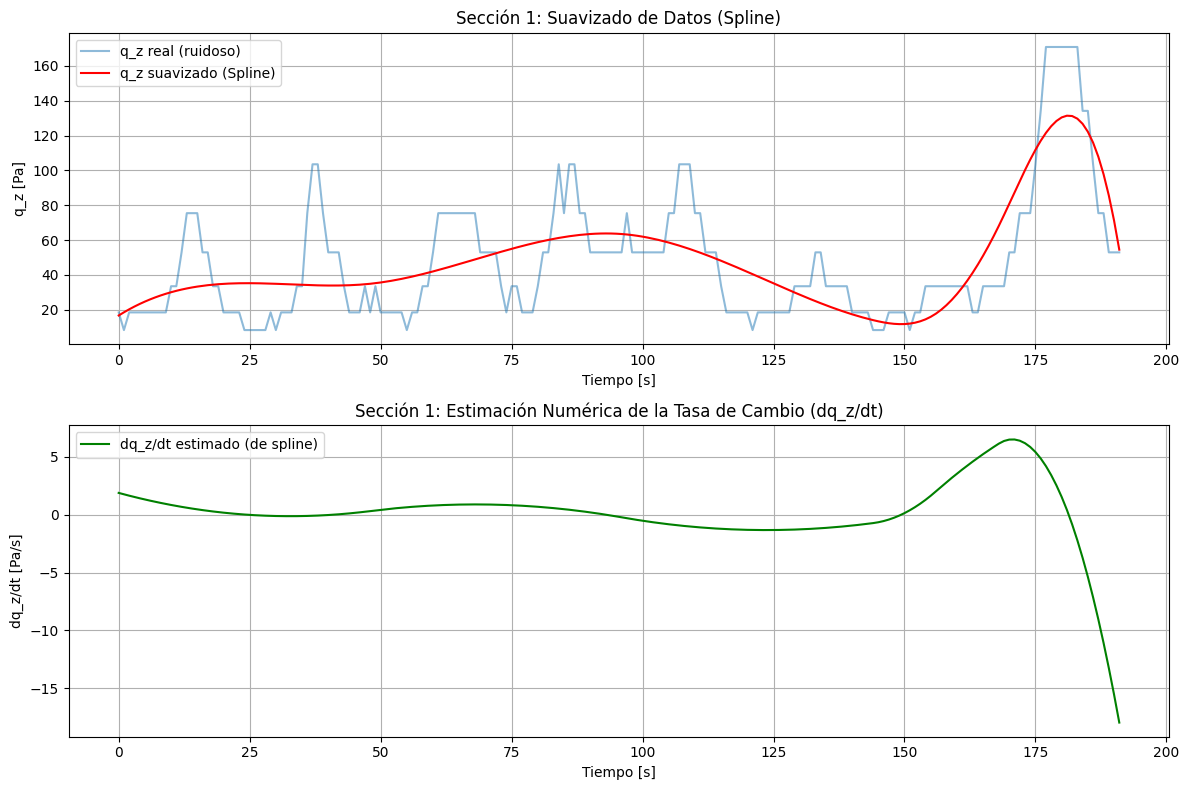

In [ ]:
spl = UnivariateSpline(t, qz, s=1e5) # Ejemplo con un valor de suavizado (ajusta según tus datos)

# Obtener los valores suavizados de qz aplicando el spline a los tiempos originales
qz_suavizado = spl(t)

# Estimar la derivada dq_z/dt de la curva suavizada.
# La derivada de un spline puede calcularse analíticamente, lo que proporciona
# una estimación numérica más estable que la diferenciación de los datos ruidosos.
dqzdt_estimado = spl.derivative()(t)

# Graficar datos originales, suavizados y la derivada estimada para visualizar el efecto del suavizado
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1) # Primera subtrama para qz
plt.plot(t, qz, label='q_z real (ruidoso)', alpha=0.5) # Datos originales con transparencia
plt.plot(t, qz_suavizado, label='q_z suavizado (Spline)', color='red') # Datos suavizados
plt.xlabel('Tiempo [s]')
plt.ylabel('q_z [Pa]')
plt.title('Sección 1: Suavizado de Datos (Spline)')
plt.legend()
plt.grid(True)

plt.subplot(2, 1, 2) # Segunda subtrama para dqzdt
plt.plot(t, dqzdt_estimado, label='dq_z/dt estimado (de spline)', color='green') # Derivada estimada
plt.xlabel('Tiempo [s]')
plt.ylabel('dq_z/dt [Pa/s]')
plt.title('Sección 1: Estimación Numérica de la Tasa de Cambio (dq_z/dt)')
plt.legend()
plt.grid(True)

plt.tight_layout() # Ajustar diseño para evitar solapamiento
plt.show()

### Sección 2 · Formulación y optimización de un modelo dinámico (nueva ODE)

Planteamos la dinámica de `qz` mediante una **Ecuación Diferencial Ordinaria (ODE)**:

$$
\dot{q}_z \;=\; c_1 \;+\; c_2\,q_z \;+\; c_3\,q_z^{2} \;+\; c_4\,|q_z|^{1/2}
$$

donde:

- $\dot{q}_z$ es la derivada temporal de $q_z$ (tasa de cambio).  
- $c_1,\; c_2,\; c_3$ y $c_4$ son parámetros desconocidos que debemos estimar.

**Objetivo**  
Determinar los valores óptimos de $(c_1, c_2, c_3, c_4)$ que mejor reproduzcan la relación entre $q_z$ (suavizado) y su derivada estimada.

Sección 2: Parámetros optimizados (Nueva ODE): c1=0.067312, c2=-0.029530, c3=0.000105, c4=0.177110


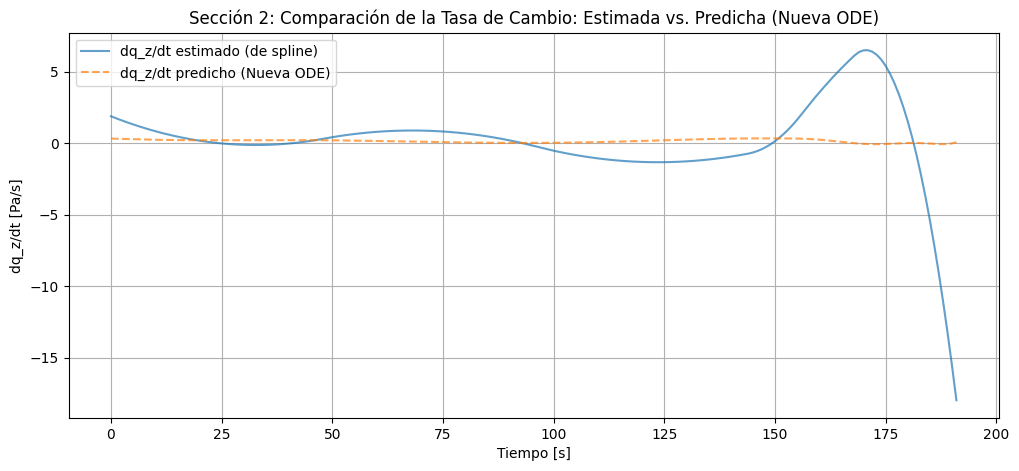

In [ ]:
# Definir la NUEVA ODE con parámetros a optimizar
def nueva_dqzdt_modelo(qz_vals, params):
    # params es una lista o array con [c1, c2, c3, c4]
    c1, c2, c3, c4 = params
    # Asegurarse de que los términos manejen el signo correctamente
    # qz (presión dinámica) debería ser >= 0, pero abs() añade robustez.
    result = c1 + c2 * qz_vals + c3 * qz_vals**2 + c4 * np.abs(qz_vals)**0.5
    # Asegurarse de que el resultado es un escalar si la entrada fue escalar
    if isinstance(qz_vals, (int, float, np.floating)) and isinstance(result, np.ndarray) and result.size == 1:
        return result.item()
    return result

# Función objetivo para la optimización de la NUEVA ODE.
# Queremos encontrar los parámetros que minimicen la diferencia entre la
# derivada estimada (de la Sección 1) y la derivada predicha por nuestro modelo ODE.
# Usamos el Error Cuadrático Medio (MSE) como métrica a minimizar.
def objective_nueva_ode(params):
    dqzdt_predicho = nueva_dqzdt_modelo(qz_suavizado, params) # dqzdt predicho por el modelo para los qz suavizados
    return np.mean((dqzdt_predicho - dqzdt_estimado)**2) # MSE entre la derivada predicha y la estimada

# Condiciones iniciales para los parámetros (c1, c2, c3, c4) para iniciar la optimización
params0 = [0.0, 0.0, 0.0, 0.0] # Un punto de partida simple (parámetros cero)

# Optimizar los parámetros usando un método numérico (L-BFGS-B).
# minimize busca los valores de 'params' que hacen que 'objective_nueva_ode' sea mínima.
opt_nueva = minimize(objective_nueva_ode, params0, method='L-BFGS-B') # Otros métodos: 'Powell', 'Nelder-Mead'

# Obtener los parámetros óptimos encontrados por el optimizador
params_opt_nueva = opt_nueva.x
print(f"Sección 2: Parámetros optimizados (Nueva ODE): c1={params_opt_nueva[0]:.6f}, c2={params_opt_nueva[1]:.6f}, c3={params_opt_nueva[2]:.6f}, c4={params_opt_nueva[3]:.6f}")

# --- Comparar la derivada estimada con la predicha por la nueva ODE ---
# Calculamos la derivada predicha por el modelo usando los parámetros óptimos
dqzdt_predicho_opt = nueva_dqzdt_modelo(qz_suavizado, params_opt_nueva)

# Graficar para ver qué tan bien el modelo predice la derivada estimada
plt.figure(figsize=(12, 5))
plt.plot(t, dqzdt_estimado, label='dq_z/dt estimado (de spline)', alpha=0.7)
plt.plot(t, dqzdt_predicho_opt, label='dq_z/dt predicho (Nueva ODE)', alpha=0.7, linestyle='--') # Predicción del modelo
plt.xlabel('Tiempo [s]')
plt.ylabel('dq_z/dt [Pa/s]')
plt.title('Sección 2: Comparación de la Tasa de Cambio: Estimada vs. Predicha (Nueva ODE)')
plt.legend()
plt.grid(True)
plt.show()

### Sección 3 · Integración numérica del modelo y detección de anomalías

Con los parámetros de la ODE ya calibrados, simulamos la evolución de `qz` usando **Runge-Kutta de 4.º orden (RK4)**:

* **Condición inicial:** valor de `qz` en $t_0$.  
* **Paso de tiempo:** igual al de los datos $\Delta t$.  
* **Salida:** serie predicha $q_z(t)$ para todo el intervalo de estudio.

Al contrastar la trayectoria integrada con las mediciones reales podemos **detectar anomalías**: cuando $\lvert q_{z,\mathrm{obs}} - q_{z,\mathrm{pred}} \rvert > \gamma \sigma$
el punto se marca como atípico.



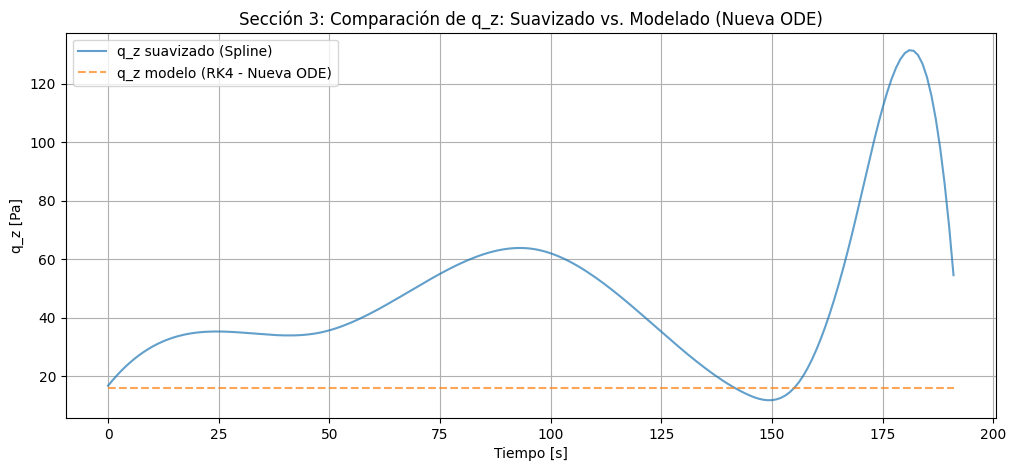

In [ ]:
# Runge-Kutta 4º orden adaptado para la nueva ODE
def rk4_step_nueva(qz_i, t_i, h, params):
    # Implementación del paso RK4 para la nueva_dqzdt_modelo
    k1 = nueva_dqzdt_modelo(qz_i, params)
    k2 = nueva_dqzdt_modelo(qz_i + 0.5*h*k1, params) # Nota: la nueva ODE no depende de t explícitamente
    k3 = nueva_dqzdt_modelo(qz_i + 0.5*h*k2, params)
    k4 = nueva_dqzdt_modelo(qz_i + h*k3, params)
    result = qz_i + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    # Asegurarse de que el resultado es un escalar si qz_i fue escalar
    if isinstance(qz_i, (int, float, np.floating)) and isinstance(result, np.ndarray) and result.size == 1:
        return result.item()
    return result

# Función para integrar la nueva ODE a lo largo de todo el vector de tiempo
def integrate_rk4_nueva(qz0, t, params):
    # qz0: Condición inicial (valor de qz en t[0])
    # t: Vector de tiempos
    # params: Parámetros optimizados de la ODE
    qz_model_nueva = np.zeros_like(t) # Array para almacenar la solución integrada
    qz_model_nueva[0] = qz0 # Establecer la condición inicial

    # Iterar sobre el tiempo aplicando el paso RK4
    for i in range(len(t)-1):
        # Calcular el siguiente valor de qz_model usando el paso RK4
        next_qz = rk4_step_nueva(qz_model_nueva[i], t[i], h, params)
        # Asignar el resultado (asegurando que sea escalar)
        if isinstance(next_qz, np.ndarray) and next_qz.size == 1:
             qz_model_nueva[i+1] = next_qz.item()
        else:
            qz_model_nueva[i+1] = next_qz
    return qz_model_nueva

# Integrar con los parámetros óptimos de la nueva ODE.
# Usamos el primer valor de qz suavizado como condición inicial para el modelo.
qz_model_nueva_sol = integrate_rk4_nueva(qz_suavizado[0], t, params_opt_nueva)

# Graficar la solución de la nueva ODE vs datos suavizados para ver qué tan bien predice qz
plt.figure(figsize=(12, 5))
plt.plot(t, qz_suavizado, label='q_z suavizado (Spline)', alpha=0.7) # Datos suavizados
plt.plot(t, qz_model_nueva_sol, label='q_z modelo (RK4 - Nueva ODE)', alpha=0.7, linestyle='--') # Solución del modelo
plt.xlabel('Tiempo [s]')
plt.ylabel('q_z [Pa]')
plt.title('Sección 3: Comparación de q_z: Suavizado vs. Modelado (Nueva ODE)')
plt.legend()
plt.grid(True)
plt.show()



### Análisis de error y detección de anomalías

**Explicación**  
La diferencia entre los datos observados (originales o suavizados) y la predicción del modelo (la solución integrada) representa el *error* del modelo, definido como  

$$
e(t) \;=\; q_{z,\mathrm{obs}}(t) \;-\; q_{z,\mathrm{pred}}(t)
$$

Los puntos donde $|e(t)|$ es suficientemente grande pueden indicar **anomalías**: eventos o mediciones que no se ajustan al comportamiento típico descrito por nuestro modelo.

Para detectar anomalías en los datos **originales** compararemos el modelo integrado con los valores originales de $q_z$.


Sección 3: RMSE (Nueva ODE vs Original): 48.1658, R² (Nueva ODE vs Original): -0.7327
Sección 3: Anomalías detectadas (Nueva ODE vs Original): 20


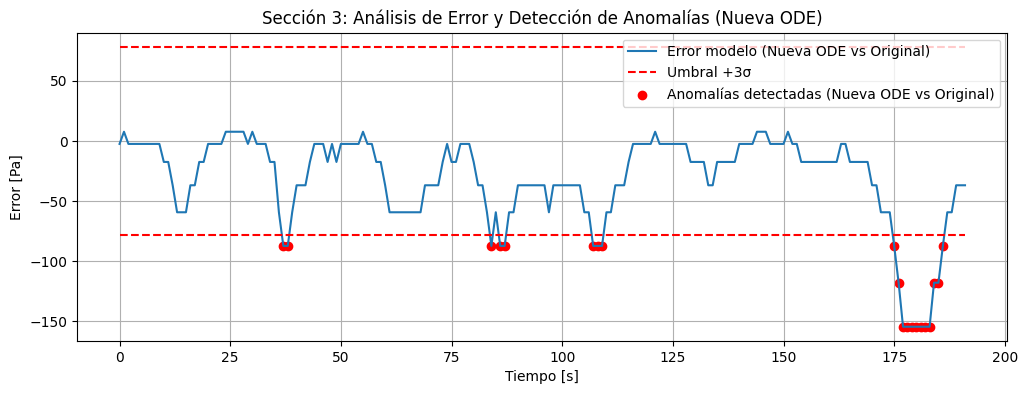

In [ ]:
error_nueva_ode = qz_model_nueva_sol - qz # Error entre la solución del modelo y los datos ORIGINALES

# Métricas de rendimiento del modelo (opcional, pero útil para tu exposición)
rmse_nueva = np.sqrt(np.mean(error_nueva_ode**2)) # Raíz del Error Cuadrático Medio
# R² explica qué proporción de la varianza de los datos originales es explicada por el modelo.
r2_nueva = 1 - (np.sum(error_nueva_ode**2) / np.sum((qz - np.mean(qz))**2)) # R2 vs datos originales

print(f"Sección 3: RMSE (Nueva ODE vs Original): {rmse_nueva:.4f}, R² (Nueva ODE vs Original): {r2_nueva:.4f}")

# Detección de anomalías: Usando el error del modelo (Nueva ODE vs datos originales)
# Definimos un umbral para identificar anomalías.
# Un método común es usar un múltiplo de la desviación estándar del error.
# Aquí usamos gamma_umbral veces la desviación estándar (regla de n-sigma) por encima de la media del error.
threshold_nueva = np.mean(error_nueva_ode) + gamma_umbral*np.std(error_nueva_ode)

# Identificamos los índices de los puntos donde el valor absoluto del error supera el umbral
anomalies_nueva = np.where(np.abs(error_nueva_ode) > threshold_nueva)[0]
print(f"Sección 3: Anomalías detectadas (Nueva ODE vs Original): {len(anomalies_nueva)}")

# Visualizar el error y las anomalías detectadas
plt.figure(figsize=(12,4))
plt.plot(t, error_nueva_ode, label='Error modelo (Nueva ODE vs Original)')
plt.hlines(threshold_nueva, t.min(), t.max(), colors='r', linestyles='--', label='Umbral +3σ') # Línea horizontal del umbral positivo
plt.hlines(-threshold_nueva, t.min(), t.max(), colors='r', linestyles='--') # Línea horizontal del umbral negativo
plt.scatter(t[anomalies_nueva], error_nueva_ode[anomalies_nueva], color='r', label='Anomalías detectadas (Nueva ODE vs Original)') # Marcar los puntos anómalos
plt.xlabel('Tiempo [s]')
plt.ylabel('Error [Pa]')
plt.title('Sección 3: Análisis de Error y Detección de Anomalías (Nueva ODE)')
plt.legend()
plt.grid(True)
plt.show()

### Sección opcional: detección de anomalías directamente del suavizado

**Explicación**  
Un enfoque más simple es comparar los datos originales directamente con los datos suavizados.  
Definimos el error como  

$$
e_s(t) \;=\; q_{z,\mathrm{obs}}(t) \;-\; q_{z,\mathrm{smooth}}(t)
$$

Los puntos donde $|e_s(t)|$ es lo suficientemente grande pueden considerarse **anomalías**, pues indican picos o caídas bruscas que el suavizado (la tendencia esperada) ha “ignorado”.


Sección Opcional: Anomalías detectadas (Suavizado vs Original): 2


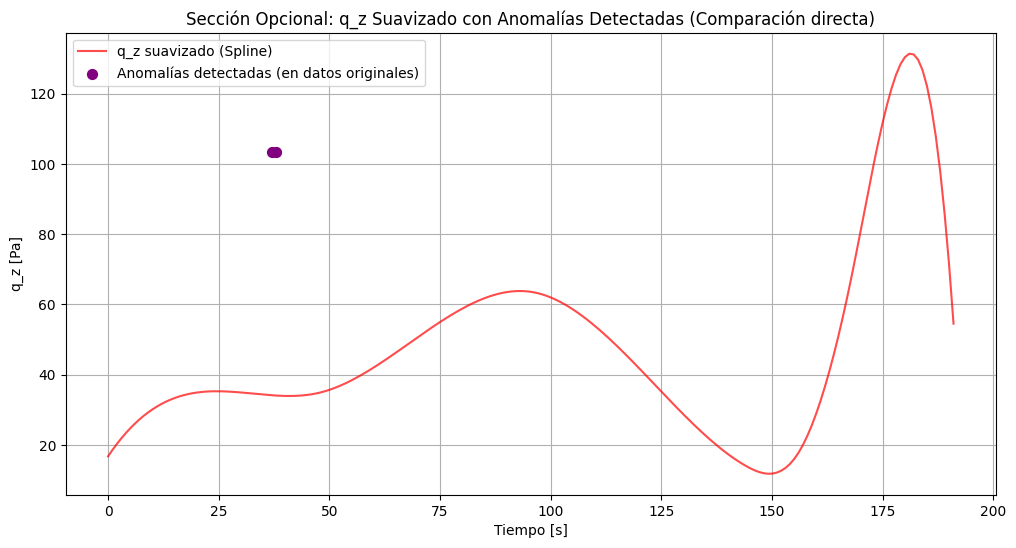

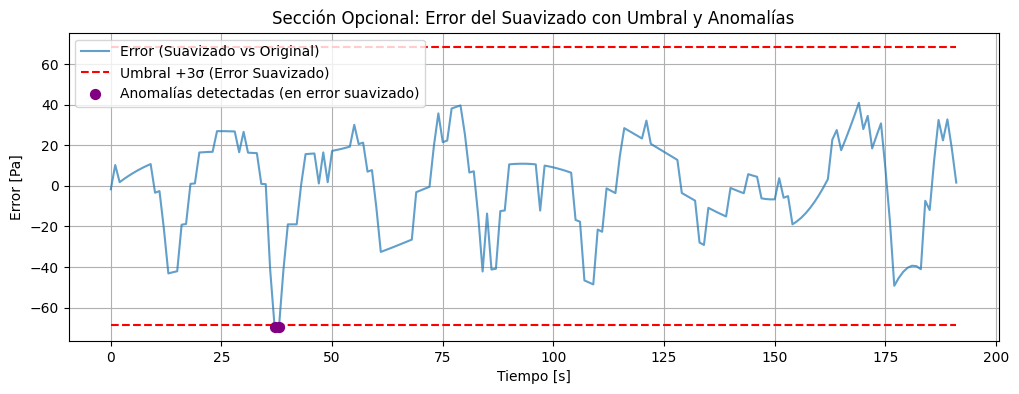

In [ ]:
# Calculamos el error entre los datos originales y los datos suavizados
error_suavizado = qz_suavizado - qz

# Calculamos un umbral para detectar anomalías basado en el error del suavizado
# Usamos gamma_umbral veces la desviación estándar del error del suavizado como umbral.
threshold_suavizado = np.mean(error_suavizado) + gamma_umbral * np.std(error_suavizado)

# Identificamos los índices donde el error absoluto supera el umbral
anomalies_indices_suavizado = np.where(np.abs(error_suavizado) > threshold_suavizado)[0]

print(f"Sección Opcional: Anomalías detectadas (Suavizado vs Original): {len(anomalies_indices_suavizado)}")

# Visualizar el qz suavizado y marcar las anomalías detectadas en los datos originales
plt.figure(figsize=(12, 6))
plt.plot(t, qz_suavizado, label='q_z suavizado (Spline)', color='red', alpha=0.7)
plt.scatter(t[anomalies_indices_suavizado], qz[anomalies_indices_suavizado], color='purple', s=50, zorder=5, label='Anomalías detectadas (en datos originales)') # Marcar en los datos ORIGINALES
plt.xlabel('Tiempo [s]')
plt.ylabel('q_z [Pa]')
plt.title('Sección Opcional: q_z Suavizado con Anomalías Detectadas (Comparación directa)')
plt.legend()
plt.grid(True)
plt.show()

# Opcionalmente, visualizar el error del suavizado y el umbral
plt.figure(figsize=(12, 4))
plt.plot(t, error_suavizado, label='Error (Suavizado vs Original)', alpha=0.7)
plt.hlines(threshold_suavizado, t.min(), t.max(), colors='r', linestyles='--', label='Umbral +3σ (Error Suavizado)')
plt.hlines(-threshold_suavizado, t.min(), t.max(), colors='r', linestyles='--')
plt.scatter(t[anomalies_indices_suavizado], error_suavizado[anomalies_indices_suavizado], color='purple', s=50, zorder=5, label='Anomalías detectadas (en error suavizado)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Error [Pa]')
plt.title('Sección Opcional: Error del Suavizado con Umbral y Anomalías')
plt.legend()
plt.grid(True)
plt.show()


--- Modelo Original (Comparación) ---
Decay rate optimizado (modelo original): 0.010000


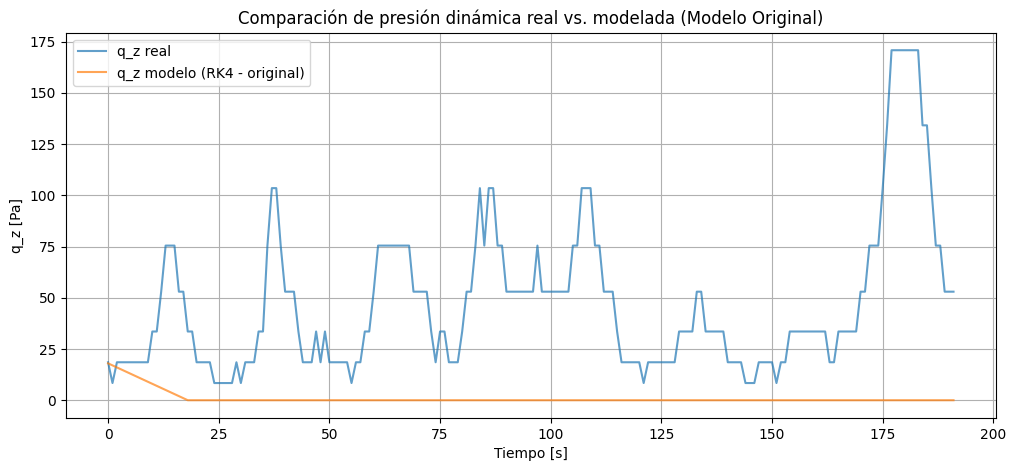

RMSE (Modelo Original): 59.5425, R² (Modelo Original): -1.6479
Anomalías detectadas (Modelo Original): 47


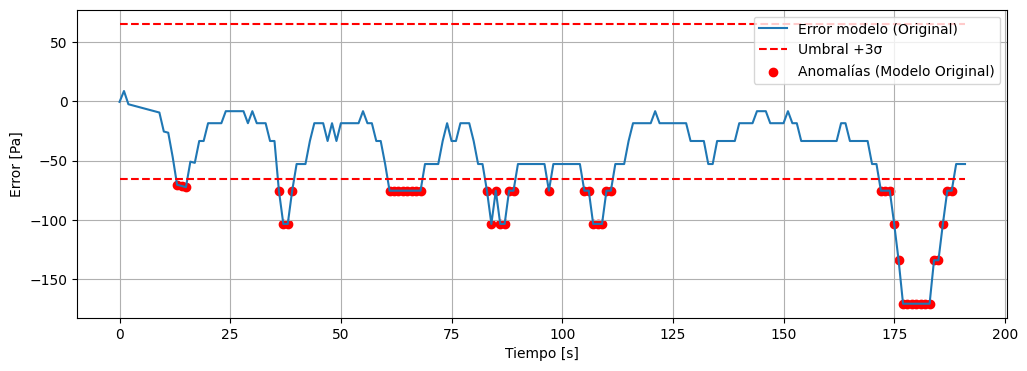

In [ ]:
# Definir ODE (un modelo simple de decaimiento: dqzdt = -decay_rate * qz * |qz|^0.5)
# Este modelo se optimiza directamente contra los datos originales, a diferencia de la NUEVA ODE.
def dqzdt(qz, t, decay_rate):
    # Este modelo asume un decaimiento proporcional a qz^1.5
    return -decay_rate * qz * np.abs(qz)**0.5

# Runge-Kutta 4º orden para el modelo original
def rk4_step(qz_i, t_i, h, decay_rate):
    k1 = dqzdt(qz_i, t_i, decay_rate)
    k2 = dqzdt(qz_i + 0.5*h*k1, t_i + 0.5*h, decay_rate)
    k3 = dqzdt(qz_i + 0.5*h*k2, t_i + 0.5*h, decay_rate)
    k4 = dqzdt(qz_i + h*k3, t_i + h, decay_rate)
    result = qz_i + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
    if isinstance(result, np.ndarray) and result.size == 1:
        return result.item()
    return result

# Función para integrar todo el vector (modelo original)
def integrate_rk4(qz0, t, decay_rate):
    qz_model = np.zeros_like(t)
    qz_model[0] = qz0
    for i in range(len(t)-1):
        next_qz = rk4_step(qz_model[i], t[i], h, decay_rate)
        if isinstance(next_qz, np.ndarray) and next_qz.size == 1:
             qz_model[i+1] = next_qz.item()
        else:
            qz_model[i+1] = next_qz
    return qz_model

# Optimización decay_rate (usando los datos originales 'qz')
decay_rate0 = 0.01
def objective(dr):
    # Esta función objetivo compara el modelo integrado con los datos ORIGINALES 'qz'.
    qz_pred = integrate_rk4(qz[0], t, dr[0]) # dr es un array porque minimize lo pasa así
    return np.mean((qz_pred - qz)**2)

# Optimizar el parámetro decay_rate para el modelo original
opt = minimize(objective, [decay_rate0], bounds=[(0, 1)], method='L-BFGS-B')
decay_rate_opt = opt.x[0]
print(f"\n--- Modelo Original (Comparación) ---")
print(f"Decay rate optimizado (modelo original): {decay_rate_opt:.6f}")

# Integrar con parámetro óptimo (modelo original)
qz_model = integrate_rk4(qz[0], t, decay_rate_opt)

# Graficar modelo vs datos reales (modelo original vs datos originales)
plt.figure(figsize=(12, 5))
plt.plot(t, qz, label='q_z real', alpha=0.7)
plt.plot(t, qz_model, label='q_z modelo (RK4 - original)', alpha=0.7)
plt.xlabel('Tiempo [s]')
plt.ylabel('q_z [Pa]')
plt.title('Comparación de presión dinámica real vs. modelada (Modelo Original)')
plt.legend()
plt.grid(True)
plt.show()

# Análisis de error (modelo original vs datos originales)
error = qz_model - qz
rmse = np.sqrt(np.mean(error**2))
r2 = 1 - (np.sum(error**2) / np.sum((qz - np.mean(qz))**2))
print(f"RMSE (Modelo Original): {rmse:.4f}, R² (Modelo Original): {r2:.4f}")

# Detección de anomalías (modelo original vs datos originales)
threshold = np.mean(error) + 3*np.std(error)
anomalies = np.where(np.abs(error) > threshold)[0]
print(f"Anomalías detectadas (Modelo Original): {len(anomalies)}")

plt.figure(figsize=(12,4))
plt.plot(t, error, label='Error modelo (Original)')
plt.hlines(threshold, t.min(), t.max(), colors='r', linestyles='--', label='Umbral +3σ')
plt.hlines(-threshold, t.min(), t.max(), colors='r', linestyles='--')
plt.scatter(t[anomalies], error[anomalies], color='r', label='Anomalías (Modelo Original)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Error [Pa]')
plt.legend()
plt.grid(True)
plt.show()

### Cálculo de la precisión del método RK4 para distintos pasos ($h$)

A continuación se define:

1. Define (o vuelve a definir) las funciones auxiliares `rk4_step_compare` e `integrate_rk4_compare`.  
2. Integra la ODE con pasos $$h = 1,\; \tfrac12,\; \tfrac14,\; \tfrac18$$.  
3. Calcula el error $$e_h(t)=q_{z,\mathrm{pred}}(t)-q_{z,\mathrm{smooth}}(t)$$  
   y su **RMSE** para cada $h$.  
4. Guarda los resultados en `results_df` para usarlos más tarde.


In [ ]:
# Redefinir la función de paso RK4 para mayor claridad con distintos valores de h
def rk4_step_compare(qz_i, t_i, h_step, params):
    # Usa la función nueva_dqzdt_modelo definida anteriormente
    k1 = nueva_dqzdt_modelo(qz_i, params)
    k2 = nueva_dqzdt_modelo(qz_i + 0.5 * h_step * k1, params)
    k3 = nueva_dqzdt_modelo(qz_i + 0.5 * h_step * k2, params)
    k4 = nueva_dqzdt_modelo(qz_i + h_step * k3, params)
    result = qz_i + (h_step / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
    # Devolver un escalar en lugar de un array de tamaño 1 si procede
    if isinstance(result, np.ndarray) and result.size == 1:
        return result.item()
    return result


# Función para integrar la ODE con un tamaño de paso h_solve dado
def integrate_rk4_compare(qz0, t_full, h_solve, params):
    # t_full es el vector de tiempo original
    # h_solve es el tamaño de paso para la integración RK4
    # Generamos un nuevo vector de tiempo basado en h_solve
    t_solve = np.arange(t_full[0], t_full[-1] + h_solve, h_solve)

    # Asegurar que el último punto de t_full esté incluido
    if t_solve[-1] < t_full[-1]:
        t_solve = np.append(t_solve, t_full[-1])

    qz_model_solve = np.zeros_like(t_solve)
    qz_model_solve[0] = qz0

    for i in range(len(t_solve) - 1):
        # El paso real que se usa en rk4_step es la diferencia entre los puntos consecutivos de t_solve
        current_h_step = t_solve[i + 1] - t_solve[i]
        next_qz = rk4_step_compare(qz_model_solve[i], t_solve[i], current_h_step, params)
        if isinstance(next_qz, np.ndarray) and next_qz.size == 1:
            qz_model_solve[i + 1] = next_qz.item()
        else:
            qz_model_solve[i + 1] = next_qz

    # Para comparar con los datos suavizados, interpolamos la solución RK4 a los puntos de t_full
    # Usamos UnivariateSpline para la interpolación (s=0 asegura interpolación exacta)
    spl_model = UnivariateSpline(t_solve, qz_model_solve, s=0)
    qz_model_interpolated = spl_model(t_full)

    return qz_model_interpolated


# Definir los distintos tamaños de paso h a probar
h_values = [1 / 2, 1, 12, 48]

# Usar el primer valor de los datos suavizados como condición inicial
qz0 = qz_suavizado[0]

# Almacenar los errores (por ejemplo, RMSE) para cada valor de h
errors = {}

# Iterar sobre los distintos valores de h, integrar y calcular el error
for h_solve in h_values:
    print(f"Integrating with h = {h_solve:.4f}")
    # Integrar el modelo usando el tamaño de paso actual h_solve
    qz_model_interp = integrate_rk4_compare(qz0, t, h_solve, params_opt_nueva)

    # Calcular el error respecto a los datos suavizados (nuestra solución 'cuasi-exacta')
    # El error se evalúa en los puntos de tiempo originales t
    error_h = qz_model_interp - qz_suavizado

    # Calcular el RMSE como medida de precisión
    rmse_h = np.sqrt(np.mean(error_h**2))
    errors[h_solve] = rmse_h
    print(f"  RMSE comparado con datos suavizados: {rmse_h:.6f}")


# Crear un DataFrame para mostrar los resultados
results_df = pd.DataFrame(
    list(errors.items()),
    columns=['Step Size (h)', 'RMSE vs Smoothed Data']
)

# Mostrar la tabla
print("\nResultados de precisión del método Runge-Kutta para diferentes pasos (h):")
display(results_df)


Integrating with h = 0.5000
  RMSE comparado con datos suavizados: 26.397991
Integrating with h = 1.0000
  RMSE comparado con datos suavizados: 41.453242
Integrating with h = 12.0000
  RMSE comparado con datos suavizados: 28.202549
Integrating with h = 48.0000
  RMSE comparado con datos suavizados: 26.886877

Resultados de precisión del método Runge-Kutta para diferentes pasos (h):


,Step Size (h),RMSE vs Smoothed Data
0,0.5,26.397991
1,1.0,41.453242
2,12.0,28.202549
3,48.0,26.886877


### Visualización de las soluciones RK4 y de sus errores

A continuación se generan dos gráficas:

1. **Comparación de soluciones**: la serie suavizada (referencia) y las soluciones RK4 para cada $h$.  
2. **Errores en función del tiempo**: $e_h(t)$ para cada paso.

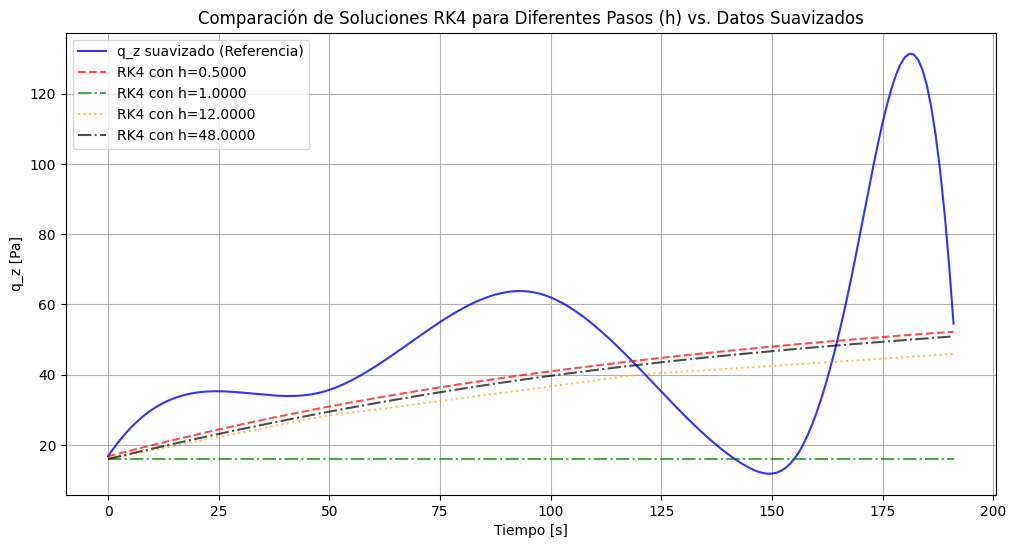

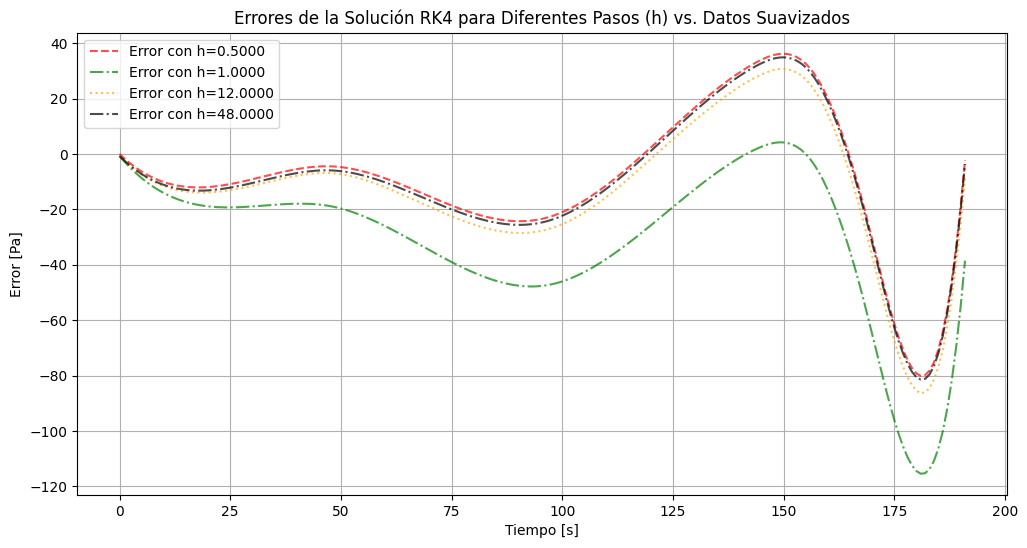

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(t, qz_suavizado, label='q_z suavizado (Referencia)', color='blue', linestyle='-', alpha=0.8)

colors = ['red', 'green', 'orange', 'black']
linestyles = ['--', '-.', ':', '-.']

for i, h_solve in enumerate(h_values):
    qz_model_interp = integrate_rk4_compare(qz0, t, h_solve, params_opt_nueva)
    plt.plot(t, qz_model_interp, label=f'RK4 con h={h_solve:.4f}', color=colors[i], linestyle=linestyles[i], alpha=0.7)

plt.xlabel('Tiempo [s]')
plt.ylabel('q_z [Pa]')
plt.title('Comparación de Soluciones RK4 para Diferentes Pasos (h) vs. Datos Suavizados')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))

for i, h_solve in enumerate(h_values):
    qz_model_interp = integrate_rk4_compare(qz0, t, h_solve, params_opt_nueva)
    error_h = qz_model_interp - qz_suavizado
    plt.plot(t, error_h, label=f'Error con h={h_solve:.4f}', color=colors[i], linestyle=linestyles[i], alpha=0.7)

plt.xlabel('Tiempo [s]')
plt.ylabel('Error [Pa]')
plt.title('Errores de la Solución RK4 para Diferentes Pasos (h) vs. Datos Suavizados')
plt.legend()
plt.grid(True)
plt.show()

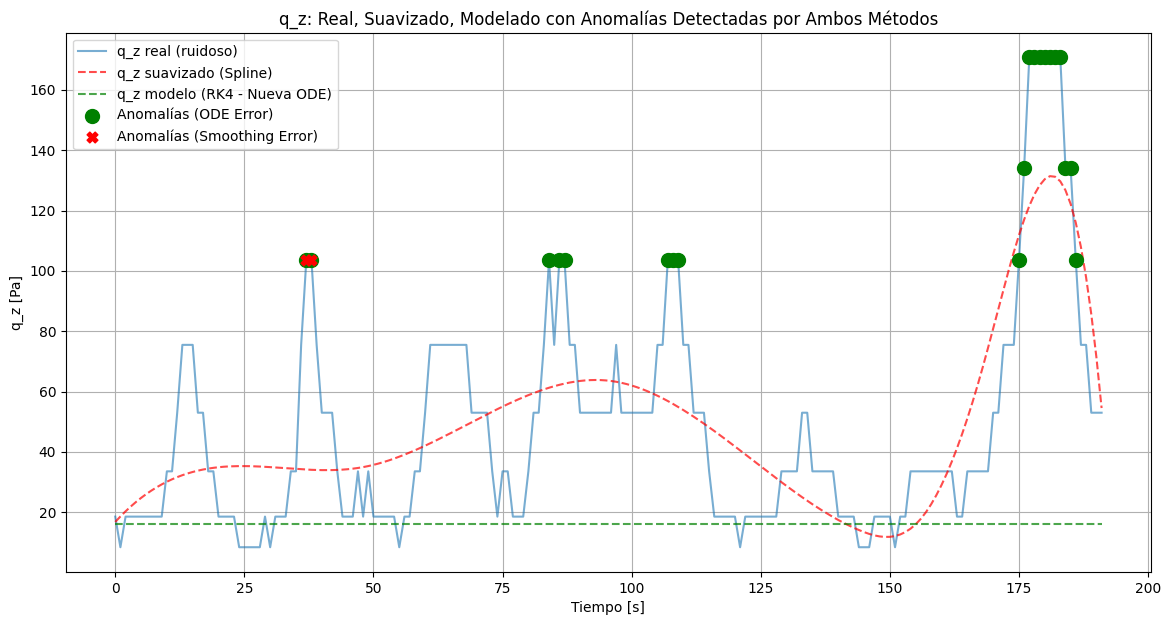

In [ ]:
# --- Visualizar Datos, Modelos y Ambas Sets de Anomalías Detectadas ---
# Graficar los datos originales, suavizado, modelo y marcar las anomalías detectadas
# por ambos métodos en los datos originales

plt.figure(figsize=(14, 7)) # Slightly larger figure

plt.plot(t, qz, label='q_z real (ruidoso)', alpha=0.6, linestyle='-') # Original data
plt.plot(t, qz_suavizado, label='q_z suavizado (Spline)', color='red', alpha=0.7, linestyle='--') # Smoothed data
plt.plot(t, qz_model_nueva_sol, label='q_z modelo (RK4 - Nueva ODE)', color='green', alpha=0.7, linestyle='--') # Model solution

# Marcar los puntos anómalos detectados por la Nueva ODE (en datos ORIGINALES)
# Using 'o' for circles
plt.scatter(t[anomalies_nueva], qz[anomalies_nueva], color='green', s=100, zorder=6, label='Anomalías (ODE Error)')

# Marcar los puntos anómalos detectados por el Suavizado (en datos ORIGINALES)
# Using '*' for stars or 'x' for crosses, or a different color circle
plt.scatter(t[anomalies_indices_suavizado], qz[anomalies_indices_suavizado], color='red', s=60, zorder=7, marker='X', label='Anomalías (Smoothing Error)')

plt.xlabel('Tiempo [s]')
plt.ylabel('q_z [Pa]')
plt.title('q_z: Real, Suavizado, Modelado con Anomalías Detectadas por Ambos Métodos')
plt.legend()
plt.grid(True)
plt.show()

### Carga y preprocesamiento del nuevo dataset (`niigata_wind_2.csv`)

Este bloque:

1. Lee el archivo **niigata_wind_2.csv**.  
2. Calcula la presión dinámica $$q_z = \tfrac12\,\rho\,(\text{wspd})^{2}$$.  
3. Construye el vector de tiempo `t_new`.  
Todo lo demás (modelos, umbrales, etc.) viene de las celdas anteriores y se
mantiene **congelado**.


In [ ]:
# Carga del nuevo dataset
df_new = pd.read_csv('niigata_wind_2.csv')


# Leer el archivo CSV con los nuevos datos
df_new = pd.read_csv('niigata_wind_2.csv')

# Calcular la presión dinámica q_z = 0.5 * ρ * v^2
df_new['qz'] = 0.5 * rho * (df_new['wspd'] ** 2)

# Crear un vector de tiempo (en segundos) — un paso por fila
df_new['time_s'] = np.arange(len(df_new))

# Convertir a arreglos NumPy para facilitar los cálculos
t_new  = df_new['time_s'].to_numpy()
qz_new = df_new['qz'].to_numpy()

### Aplicación de los modelos “congelados” a los nuevos datos

Aquí usamos **exactamente** el spline y los parámetros de la ODE que se
ajustaron con `niigata_wind.csv`:

* `spl(t_new)` → serie suavizada esperada.  
* `integrate_rk4_nueva(qz_new[0], t_new, params_opt_nueva)`  
  → predicción con la **nueva ODE**.

Ambos representan la *normalidad* aprendida del histórico.


In [ ]:
qz_suavizado_new = spl(t_new)  # extrapola si t_new excede el rango original

# 2.2 Nueva ODE: integrar con RK4 usando los parámetros congelados
#     La condición inicial es el primer valor de q_z en el nuevo dataset.
qz_model_nueva_sol_new = integrate_rk4_nueva(
    qz_new[0],   # condición inicial
    t_new,       # malla temporal del nuevo dataset
    params_opt_nueva
)

### Detección de anomalías con los umbrales históricos

Se compara la señal real del nuevo archivo con cada modelo y se marca como
anomalía todo punto donde

$$|e(t)| > \text{umbral}_{\text{histórico}}.$$


In [ ]:
# Error entre la predicción de la ODE y los datos reales
error_nueva_ode_new = qz_model_nueva_sol_new - qz_new
# Índices donde el error supera el umbral histórico
anomalies_nueva_new = np.where(np.abs(error_nueva_ode_new) > threshold_nueva)[0]

# 3.2 Error entre la serie suavizada (spline) y los datos reales
error_suavizado_new = qz_suavizado_new - qz_new
# Índices de anomalías según el umbral del suavizado
anomalies_suavizado_new = np.where(np.abs(error_suavizado_new) > threshold_suavizado)[0]

# Resumen por consola
print(f"--- Análisis de niigata_wind_2.csv ---")
print(f"Anomalías (ODE):        {len(anomalies_nueva_new)}")
print(f"Anomalías (Suavizado):  {len(anomalies_suavizado_new)}")

--- Análisis de niigata_wind_2.csv ---
Anomalías (ODE):        6
Anomalías (Suavizado):  7


### Visualización de errores y anomalías en `niigata_wind_2.csv`

La primera figura muestra el error y el umbral para la **nueva ODE**;  
la segunda, el error del **spline**;  
la tercera, las tres series $q_z$ (real, suavizada, modelada) con los puntos
anómalos resaltados.


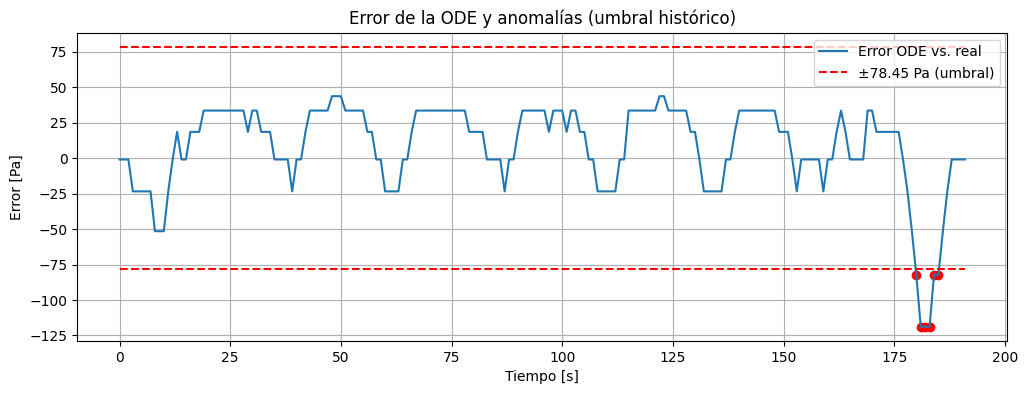

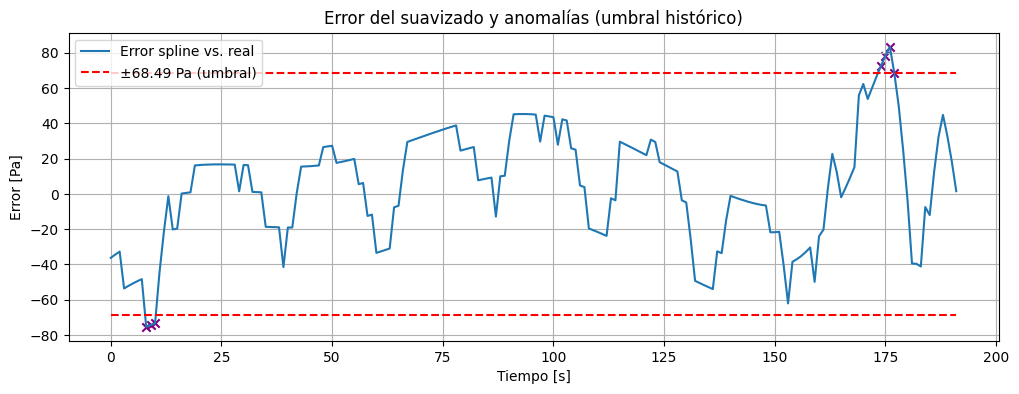

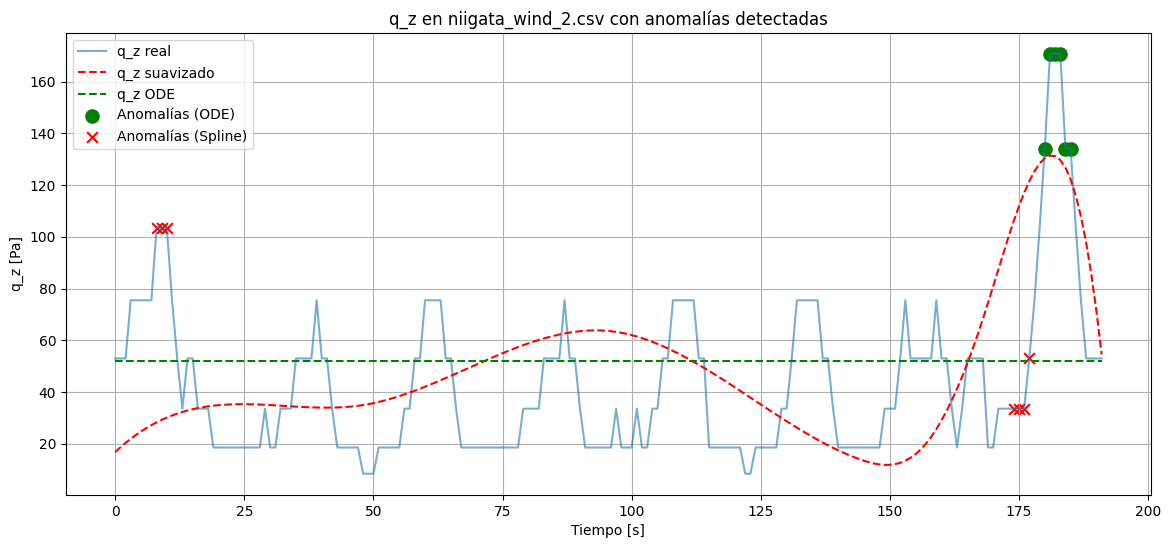

In [ ]:
# ----- 4.1 Error vs. nueva ODE ----------------
plt.figure(figsize=(12, 4))
plt.plot(t_new, error_nueva_ode_new, label='Error ODE vs. real')
plt.hlines([threshold_nueva, -threshold_nueva],
           t_new.min(), t_new.max(),
           colors='r', linestyles='--', label=f'±{threshold_nueva:.2f} Pa (umbral)')
plt.scatter(t_new[anomalies_nueva_new],
            error_nueva_ode_new[anomalies_nueva_new],
            color='r')
plt.xlabel('Tiempo [s]')
plt.ylabel('Error [Pa]')
plt.title('Error de la ODE y anomalías (umbral histórico)')
plt.legend()
plt.grid(True)
plt.show()

# ----- 4.2 Error vs. spline -------------------
plt.figure(figsize=(12, 4))
plt.plot(t_new, error_suavizado_new, label='Error spline vs. real')
plt.hlines([threshold_suavizado, -threshold_suavizado],
           t_new.min(), t_new.max(),
           colors='r', linestyles='--', label=f'±{threshold_suavizado:.2f} Pa (umbral)')
plt.scatter(t_new[anomalies_suavizado_new],
            error_suavizado_new[anomalies_suavizado_new],
            color='purple', marker='x')
plt.xlabel('Tiempo [s]')
plt.ylabel('Error [Pa]')
plt.title('Error del suavizado y anomalías (umbral histórico)')
plt.legend()
plt.grid(True)
plt.show()

# ----- 4.3 Series completas y anomalías -------
plt.figure(figsize=(14, 6))
plt.plot(t_new, qz_new,                label='q_z real',          alpha=0.6)
plt.plot(t_new, qz_suavizado_new,      label='q_z suavizado',     c='red',   ls='--')
plt.plot(t_new, qz_model_nueva_sol_new,label='q_z ODE',           c='green', ls='--')

# Puntos anómalos detectados por la ODE
plt.scatter(t_new[anomalies_nueva_new], qz_new[anomalies_nueva_new],
            color='green', s=90, label='Anomalías (ODE)')

# Puntos anómalos detectados por el suavizado
plt.scatter(t_new[anomalies_suavizado_new], qz_new[anomalies_suavizado_new],
            color='red',   s=60, marker='x', label='Anomalías (Spline)')

plt.xlabel('Tiempo [s]')
plt.ylabel('q_z [Pa]')
plt.title('q_z en niigata_wind_2.csv con anomalías detectadas')
plt.legend()
plt.grid(True)
plt.show()


# **BONUS**
**Detección de Anomalías Usando Análisis de la diferencia de la derivada local vs. global**
  
**Explicación:**
Otra metodología para detectar anomalías es analizar los datos en el dominio
de la frecuencia o a través de transformaciones que resaltan cambios abruptos.


Una anomalía a menudo se manifiesta como un cambio local y rápido en la señal.
Podemos estimar la derivada localmente (por ejemplo, usando diferencias finitas
o un suavizado con ventana pequeña) y compararla con una derivada estimada
globalmente (como la obtenida del spline suavizado en la Sección 1).
La diferencia significativa entre la derivada local y la global puede indicar una anomalía.


--- Metodología Alternativa: Análisis de Diferencia de Derivadas ---
Anomalías detectadas (Diferencia Derivadas): 2


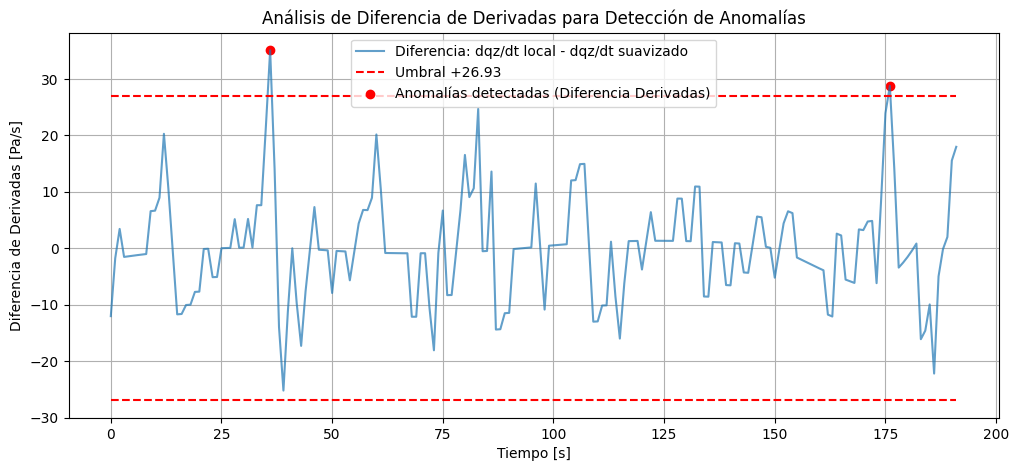

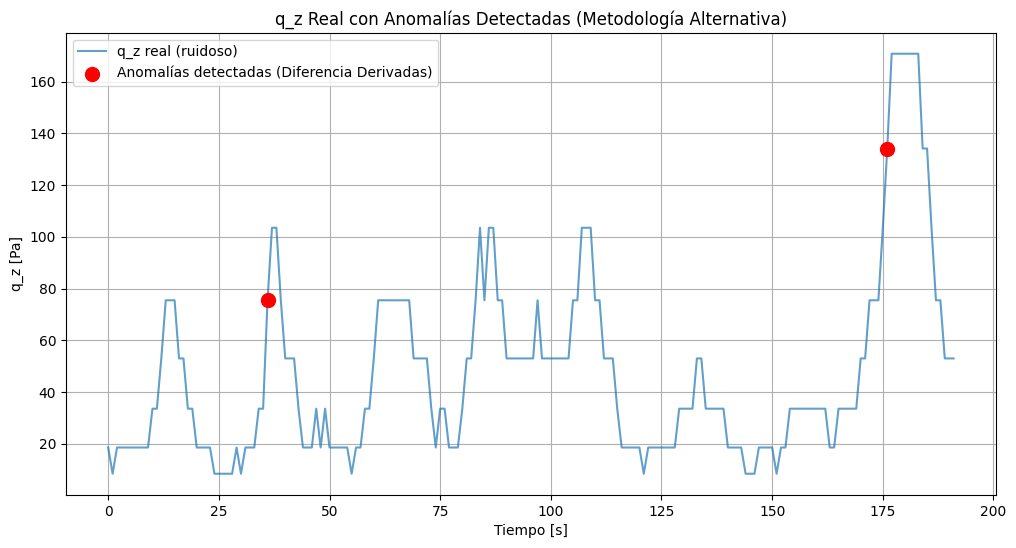

In [ ]:
from scipy.fft import fft
from scipy.signal import windows


# 1. Estimar la derivada localmente (usando diferencias finitas de los datos originales)
# Usamos una diferencia central para una mejor aproximación, cuidando los bordes.
# Esto amplificará el ruido, pero es la base para detectar cambios rápidos.
dqzdt_local_original = np.gradient(qz, t)

# 2. Comparar la derivada local con la derivada global estimada (del spline)
# Calculamos la diferencia (error) entre la derivada local ruidosa y la derivada suavizada
diff_derivada = dqzdt_local_original - dqzdt_estimado # dqzdt_estimado es del spline en Sección 1

# 3. Detectar anomalías basándose en esta diferencia de derivadas
# Los puntos donde esta diferencia es grande (positiva o negativa) indican
# que la señal original tuvo un cambio de pendiente que el modelo suavizado
# (la derivada global) no capturó, lo que podría ser una anomalía.

# Definir un umbral para la detección de anomalías en la diferencia de derivadas.
# Usamos un múltiplo de la desviación estándar de la diferencia.
mean_diff_derivada = np.mean(diff_derivada)
std_diff_derivada = np.std(diff_derivada)
threshold_laplace_like = mean_diff_derivada + gamma_umbral * std_diff_derivada

# Identificar los índices de los puntos donde el valor absoluto de la diferencia
# de derivadas supera el umbral.
anomalies_laplace_like = np.where(np.abs(diff_derivada) > threshold_laplace_like)[0]
print(f"\n--- Metodología Alternativa: Análisis de Diferencia de Derivadas ---")
print(f"Anomalías detectadas (Diferencia Derivadas): {len(anomalies_laplace_like)}")


# --- Visualizar Resultados de la Metodología Alternativa ---

# Visualizar la diferencia de derivadas y las anomalías detectadas
plt.figure(figsize=(12, 5))
plt.plot(t, diff_derivada, label='Diferencia: dqz/dt local - dqz/dt suavizado', alpha=0.7)
plt.hlines(threshold_laplace_like, t.min(), t.max(), colors='r', linestyles='--', label=f'Umbral +{threshold_laplace_like:.2f}')
plt.hlines(-threshold_laplace_like, t.min(), t.max(), colors='r', linestyles='--')
plt.scatter(t[anomalies_laplace_like], diff_derivada[anomalies_laplace_like], color='r', label='Anomalías detectadas (Diferencia Derivadas)')
plt.xlabel('Tiempo [s]')
plt.ylabel('Diferencia de Derivadas [Pa/s]')
plt.title('Análisis de Diferencia de Derivadas para Detección de Anomalías')
plt.legend()
plt.grid(True)
plt.show()

# Visualizar los datos originales y marcar las anomalías detectadas por este método
plt.figure(figsize=(12, 6))
plt.plot(t, qz, label='q_z real (ruidoso)', alpha=0.7)
# Opcional: plotear también el suavizado para contexto
# plt.plot(t, qz_suavizado, label='q_z suavizado (Spline)', color='red', alpha=0.7, linestyle='--')
plt.scatter(t[anomalies_laplace_like], qz[anomalies_laplace_like], color='red', s=100, zorder=5, label='Anomalías detectadas (Diferencia Derivadas)')
plt.xlabel('Tiempo [s]')
plt.ylabel('q_z [Pa]')
plt.title('q_z Real con Anomalías Detectadas (Metodología Alternativa)')
plt.legend()
plt.grid(True)
plt.show()